{'images_m': [[[117, 115, 53], [124, 121, 61], [100, 108, 115], [108, 106, 58], [85, 58, 62], [58, 100, 114], [118, 58, 79], [56, 54, 124], [76, 72, 82], [67, 62, 116], [63, 52, 120], [95, 68, 109], [89, 76, 85], [90, 118, 71], [92, 66, 107], [123, 66, 110], [61, 101, 126], [59, 123, 91], [125, 117, 55], [119, 115, 113], [116, 89, 103], [121, 96, 71], [83, 104, 89], [80, 98, 54], [255, 0, 0], [255, 0, 0], [255, 0, 0], [255, 0, 0], [255, 0, 0], [255, 0, 0], [255, 0, 0], [255, 0, 0], [71, 94, 91], [72, 86, 110], [118, 86, 126], [58, 77, 58], [60, 120, 81], [79, 89, 95], [74, 114, 126], [88, 66, 125], [95, 67, 90], [78, 93, 85], [84, 104, 76], [56, 65, 59], [57, 57, 60], [115, 51, 57], [114, 113, 85], [92, 89, 121], [123, 94, 88], [107, 58, 97], [80, 66, 67], [81, 126, 109], [66, 117, 84], [68, 95, 115], [59, 52, 56], [76, 120, 99], [64, 115, 71], [101, 53, 115], [64, 93, 86], [91, 114, 98], [100, 93, 73], [117, 121, 123], [107, 89, 70], [84, 106, 70]], [[72, 114, 52], [118, 119, 100], [7

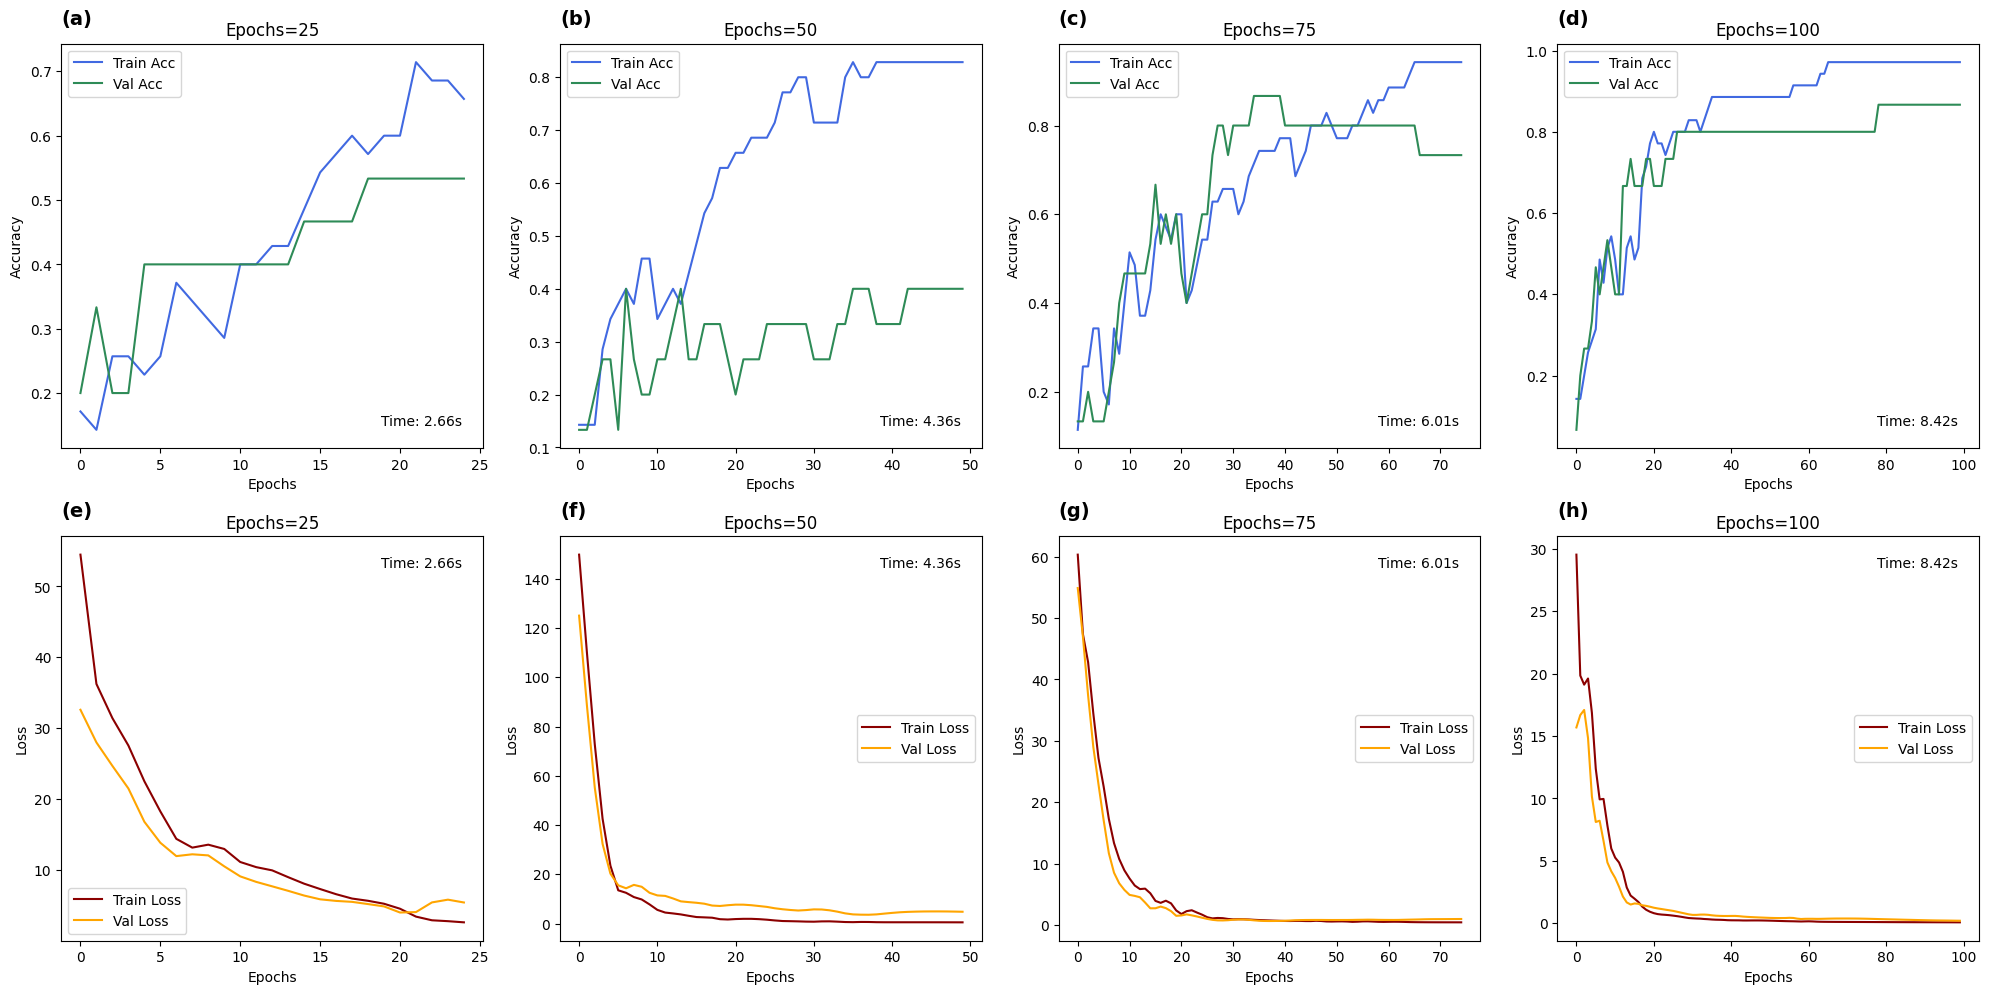


All training histories saved to cnn_training_results.json


In [ ]:
#***************************************************************************************************#
# CODE DEVELOPED BY CHISOMO DAKA - MARCH, 2025 (WITS UNIVERSITY - NANO-SCALE TRANSPORT PHYSICS LAB) #
#***************************************************************************************************#
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import time
import matplotlib.pyplot as plt

#RGB TO INT DATASET IMAGE CONVERSION
#Forward
def rgb_to_int_dataset(rgb_image_dataset):
    """
    Converts a dataset of RGB images to integer-represented pixels.
    """
    processed_dataset = []
    # Iterate through each image in the dataset
    for image in rgb_image_dataset:
        new_image = []
        # Iterate through each of the 64 pixels in the image
        for pixel in image:
            # Unpack the r, g, b values from the pixel list
            r, g, b = pixel
            
            # Apply the bit-shifting formula to get a unique integer
            integer_value = (r << 16) | (g << 8) | b
            
            # Add the new integer pixel to our new image representation
            new_image.append(integer_value)
        
        # Add the fully processed image to our new dataset
        processed_dataset.append(new_image)
        
    return processed_dataset
#Reverse
def int_to_rgb_dataset(int_image_dataset):
    """
    Converts a dataset of integer-represented pixels back to RGB images.
    """
    rgb_dataset = []
    # Iterate through each image in the integer dataset
    for integer_image in int_image_dataset:
        new_image = []
        # Iterate through each of the 64 integer pixels in the image
        for integer_pixel in integer_image:
            # Apply bit-shifting and masking to extract r, g, b values
            # Extract red: shift right by 16 bits and mask
            r = (integer_pixel >> 16) & 0xFF
            
            # Extract green: shift right by 8 bits and mask
            g = (integer_pixel >> 8) & 0xFF
            
            # Extract blue: no shift needed, just mask
            b = integer_pixel & 0xFF
            
            # Add the [r, g, b] pixel to our new image representation
            new_image.append([r, g, b])
        
        # Add the fully processed image to our new dataset
        rgb_dataset.append(new_image)
        
    return rgb_dataset

# ===========================================================
# Load the existing No-QCNN image dataset -> To Bench Mark
# ===========================================================
json_file_path = "insert_file_location"
    
with open(json_file_path, 'r') as f:
    data = json.load(f)
print(data)

n_pix = 8 # n_pix = 8 -> Multi-Class (8x8 Images) | n_pix = 4 -> Binary (8x8 Images)

images_m = np.array(data["images_m"], dtype=np.int32).reshape(-1, n_pix, n_pix, 3)
labels_m = np.array(data["labels_m"], dtype=str)
train_images_m = np.array(data["train_images_m"], dtype=np.int32).reshape(-1, n_pix, n_pix, 3)
train_labels_m = np.array(data["train_labels_m"], dtype=str)
test_images_m = np.array(data["test_images_m"], dtype=np.int32).reshape(-1, n_pix, n_pix, 3)
test_labels_m = np.array(data["test_labels_m"], dtype=str)

# Convert labels to [0, 5] - 6 labels
train_labels_m = np.array([
    0 if np.array_equal(tr_label, [-1, "R"]) else
    1 if np.array_equal(tr_label, [-1, "G"]) else
    2 if np.array_equal(tr_label, [-1, "B"]) else
    3 if np.array_equal(tr_label, [+1, "R"]) else
    4 if np.array_equal(tr_label, [+1, "G"]) else
    5 #if np.array_equal(tr_label, [+1, "B"])
    for tr_label in train_labels_m
])
test_labels_m = np.array([
    0 if np.array_equal(te_label, [-1, "R"]) else
    1 if np.array_equal(te_label, [-1, "G"]) else
    2 if np.array_equal(te_label, [-1, "B"]) else
    3 if np.array_equal(te_label, [+1, "R"]) else
    4 if np.array_equal(te_label, [+1, "G"]) else
    5 #if np.array_equal(te_label, [+1, "B"])
    for te_label in test_labels_m
])
# Ensure labels are integers
train_labels_m = train_labels_m.astype(np.int32)
test_labels_m = test_labels_m.astype(np.int32)
#Normalize
train_images_m = train_images_m.astype(np.float32)
test_images_m  = test_images_m.astype(np.float32)

print(f"Loaded {len(images_m)} images of shape {images_m.shape[1:]}")
#print(images_m)
num_classes = len(np.unique(train_labels_m))
print("This loaded dataset has ", num_classes, " classes")

# ===============================
# Define CNN builder - Multi-Class Classification (configurable to Binary)
# ===============================
def build_simple_cnn(input_shape=(n_pix, n_pix, 3), num_classes=6):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# ===============================
# Epoch settings
# ===============================
epoch_list = [25, 50, 75, 100]
results_data = {}

# Prepare figure for 8 subplots: 4 accuracy + 4 loss
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs = axs.flatten()

# ===============================
# Train CNN and plot results
# ===============================
for i, epochs in enumerate(epoch_list):
    print(f"\nTraining CNN for {epochs} epochs...")
    
    cnn_model = build_simple_cnn(input_shape=train_images_m.shape[1:], num_classes=num_classes)
    cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    
    start_time = time.time()
    history = cnn_model.fit(train_images_m, train_labels_m,
                            epochs=epochs,
                            validation_data=(test_images_m, test_labels_m),
                            verbose=0)
    end_time = time.time()
    train_time = end_time - start_time
    
    # Extract final metrics
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    # Print final metrics
    print(f"Epochs={epochs} | Final Train Acc: {final_train_acc:.4f} | Final Val Acc: {final_val_acc:.4f} | Train Loss: {final_train_loss:.4f} | Val Loss: {final_val_loss:.4f} | Training Time: {train_time:.2f}s")
    
    # Store results
    results_data[f'epochs_{epochs}'] = {
        'train_accuracy': [float(x) for x in history.history['accuracy']],
        'val_accuracy': [float(x) for x in history.history['val_accuracy']],
        'train_loss': [float(x) for x in history.history['loss']],
        'val_loss': [float(x) for x in history.history['val_loss']],
        'num_epochs': epochs,
        'train_time_sec': train_time
    }
    
    # Accuracy subplot (top row)
    ax_acc = axs[i]
    ax_acc.plot(history.history['accuracy'], label='Train Acc', color='royalblue')
    ax_acc.plot(history.history['val_accuracy'], label='Val Acc', color='seagreen')
    ax_acc.set_title(f'Epochs={epochs}')
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.text(0.95, 0.05, f'Time: {train_time:.2f}s', transform=ax_acc.transAxes,
                fontsize=10, ha='right', va='bottom')
    ax_acc.text(0, 1.085, f'({chr(97+i)})', transform=ax_acc.transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')
    
    # Loss subplot (bottom row)
    ax_loss = axs[i+4]
    ax_loss.plot(history.history['loss'], label='Train Loss', color='darkred')
    ax_loss.plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax_loss.set_title(f'Epochs={epochs}')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.text(0.95, 0.95, f'Time: {train_time:.2f}s', transform=ax_loss.transAxes,
                 fontsize=10, ha='right', va='top')
    ax_loss.text(0, 1.085, f'({chr(97+i+4)})', transform=ax_loss.transAxes,
                 fontsize=14, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()
# ===============================
# Save all training data
# ===============================
#"""
save_path = 'cnn_training_results.json'
with open(save_path, 'w') as f:
    json.dump(results_data, f, indent=4)
print(f"\nAll training histories saved to {save_path}")
#"""


<Figure size 640x480 with 0 Axes>